# Caso VetSur: Sistema predictivo de retorno de clientes
### Metodología: CRISP-DM (Cross-Industry Standard Process for Data Mining)


# Carga e Ingesta de Datos (Data understanding)

In [10]:
import pandas as pd

df = pd.read_csv('/content/sample_data/caso1_vetsur.csv', encoding='latin1', sep=',')

print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1400 entries, 0 to 1399
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   paciente_id               1400 non-null   object 
 1   sucursal                  1400 non-null   object 
 2   especie                   1400 non-null   object 
 3   raza_registrada           1400 non-null   int64  
 4   edad_mascota_anios        1400 non-null   float64
 5   tipo_atencion             1400 non-null   object 
 6   diagnostico_texto         1400 non-null   object 
 7   medico_id                 1400 non-null   object 
 8   monto_cobrado             1400 non-null   int64  
 9   costo_medicamento         1379 non-null   float64
 10  dias_desde_ultima_visita  1400 non-null   int64  
 11  visitas_historicas        1400 non-null   int64  
 12  tiene_vacunas_al_dia      1400 non-null   int64  
 13  retorno_90d               1400 non-null   int64  
dtypes: float

# Limpieza de encoding y tratamiento de nulos

In [11]:
!pip install ftfy

In [12]:
import pandas as pd
from ftfy import fix_text

df = pd.read_csv('/content/sample_data/caso1_vetsur.csv', encoding='latin1', sep=',')

def clean_vetsur_text(text):
    if pd.isna(text):
        return text
    cleaned_text = fix_text(str(text))
    return cleaned_text.lower().strip()

cols_to_fix = ['sucursal', 'tipo_atencion', 'diagnostico_texto']
for col in cols_to_fix:
    df[col] = df[col].apply(clean_vetsur_text)

df['costo_medicamento'] = df['costo_medicamento'].fillna(df['costo_medicamento'].median())
df[['sucursal', 'tipo_atencion', 'diagnostico_texto', 'costo_medicamento']].head(10)

,sucursal,tipo_atencion,diagnostico_texto,costo_medicamento
0,providencia,consulta_general,control_rutina,3500.0
1,ñuñoa,hospitalización,tumor,34600.0
2,peñalolén,hospitalización,control_rutina,31100.0
3,las_condes,consulta_especialidad,control_rutina,24700.0
4,ñuñoa,consulta_general,dermatitis,5800.0
5,peñalolén,consulta_general,fractura,4800.0
6,providencia,cirugía,artritis,74800.0
7,san_miguel,consulta_especialidad,artrítís,17600.0
8,la_florida,consulta_especialidad,esterilización,7500.0
9,pudahuel,cirugía,tumor_c,95100.0


## Normalización estándar (sin tildes ni eñes)

In [4]:
import unicodedata

def normalizar_texto(texto):
    if pd.isna(texto):
        return texto
    texto = str(texto).lower().strip()
    return ''.join(
        c for c in unicodedata.normalize('NFD', texto)
        if unicodedata.category(c) != 'Mn'
    )

columnas_texto = df.select_dtypes(include=['object']).columns
for col in columnas_texto:
    df[col] = df[col].apply(normalizar_texto)

# verificamos que ahora todo sea texto plano (ej: nunoa, cirugia, maipu)
print("columnas normalizadas exitosamente.")
print(df['sucursal'].unique())
print("tipos de atencion limpios:")
print(df['tipo_atencion'].unique())

print("\nespecies limpias:")
print(df['especie'].unique())

columnas normalizadas exitosamente.
['providencia' 'nunoa' 'penalolen' 'las_condes' 'san_miguel' 'la_florida'
 'pudahuel' 'maipu']
tipos de atencion limpios:
['consulta_general' 'hospitalizacion' 'consulta_especialidad' 'cirugia'
 'venta_producto']

especies limpias:
['gato' 'perro' 'ave' 'exa³tico']


In [14]:
df['especie'] = df['especie'].str.replace('exa³tico', 'exotico', case=False, regex=False)

print("especies limpias (ahora si que si):")
print(df['especie'].unique())

especies limpias (ahora si que si):
['gato' 'perro' 'ave' 'exÃ³tico']


# 3. Análisis exploratorio (EDA)

## Bloque 1: Distribución del target objetivo (retorno_90d)

/tmp/ipykernel_5550/1650307479.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='retorno_90d', data=df, palette=vetsur_palette)


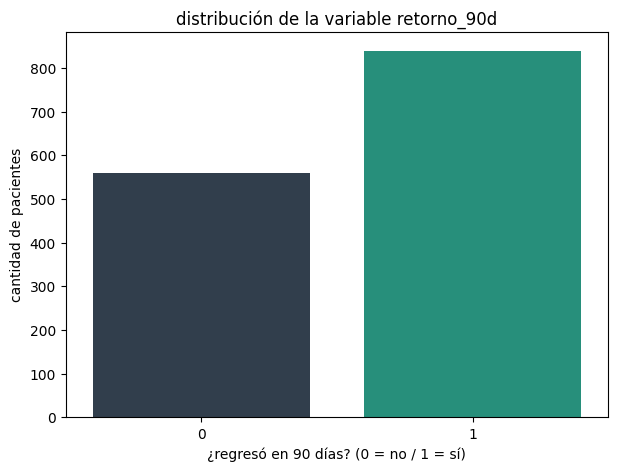

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

vetsur_palette = ["#2c3e50", "#16a085"]

plt.figure(figsize=(7,5))
sns.countplot(x='retorno_90d', data=df, palette=vetsur_palette)

plt.title('distribución de la variable retorno_90d', fontsize=12)
plt.xlabel('¿regresó en 90 días? (0 = no / 1 = sí)')
plt.ylabel('cantidad de pacientes')
plt.show()

## Bloque 2: Matriz de correlación (relación entre variables)

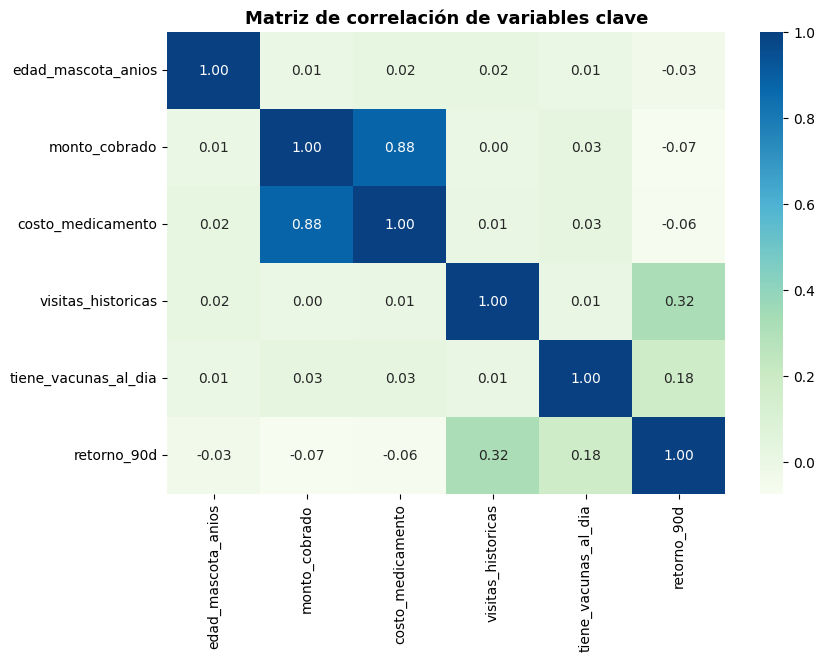

In [7]:
columnas_estudio = [
    'edad_mascota_anios', 'monto_cobrado', 'costo_medicamento',
    'visitas_historicas', 'tiene_vacunas_al_dia', 'retorno_90d'
]

plt.figure(figsize=(9,6))
sns.heatmap(df[columnas_estudio].corr(), annot=True, cmap='GnBu', fmt=".2f")

plt.title('Matriz de correlación de variables clave', fontsize=13, fontweight='bold')
plt.show()


## Bloque 3: Hallazgo de negocio (vacunas vs retorno)

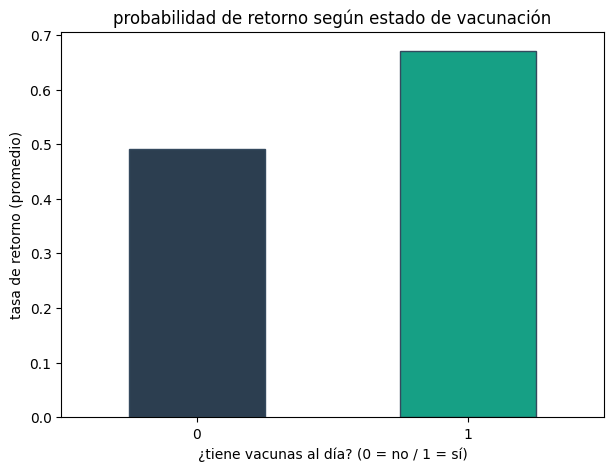

In [8]:
plt.figure(figsize=(7,5))
df.groupby('tiene_vacunas_al_dia')['retorno_90d'].mean().plot(
    kind='bar',
    color=vetsur_palette,
    edgecolor='#34495e'
)

plt.title('probabilidad de retorno según estado de vacunación', fontsize=12)
plt.xlabel('¿tiene vacunas al día? (0 = no / 1 = sí)')
plt.ylabel('tasa de retorno (promedio)')
plt.xticks(rotation=0)
plt.show()

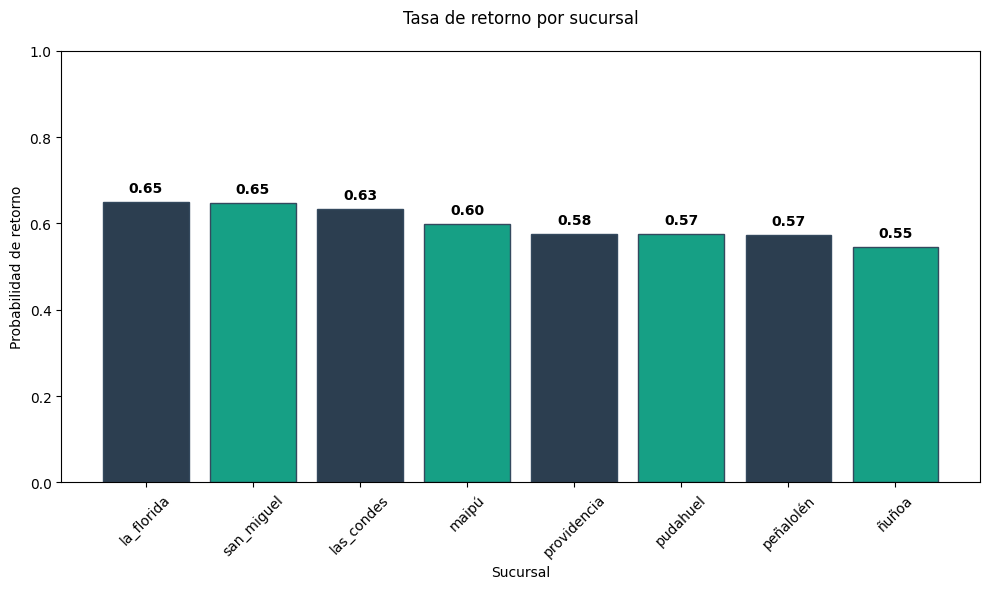

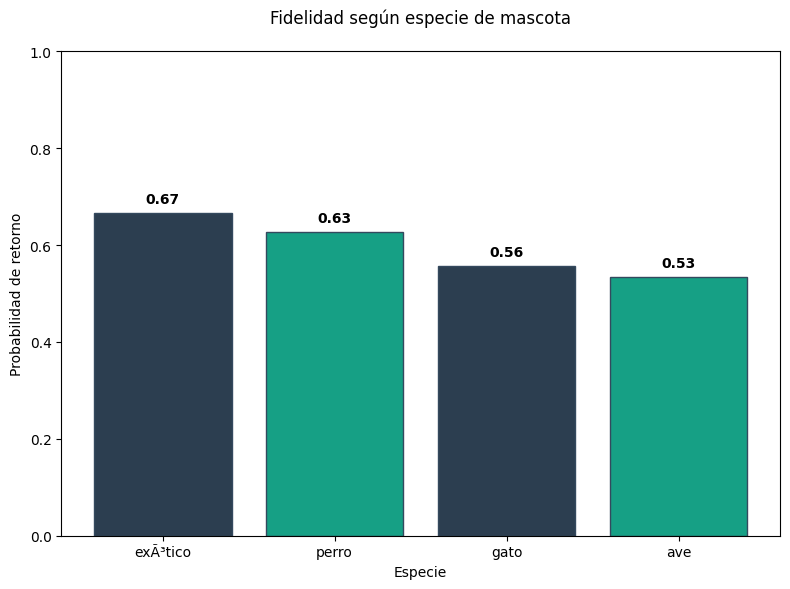

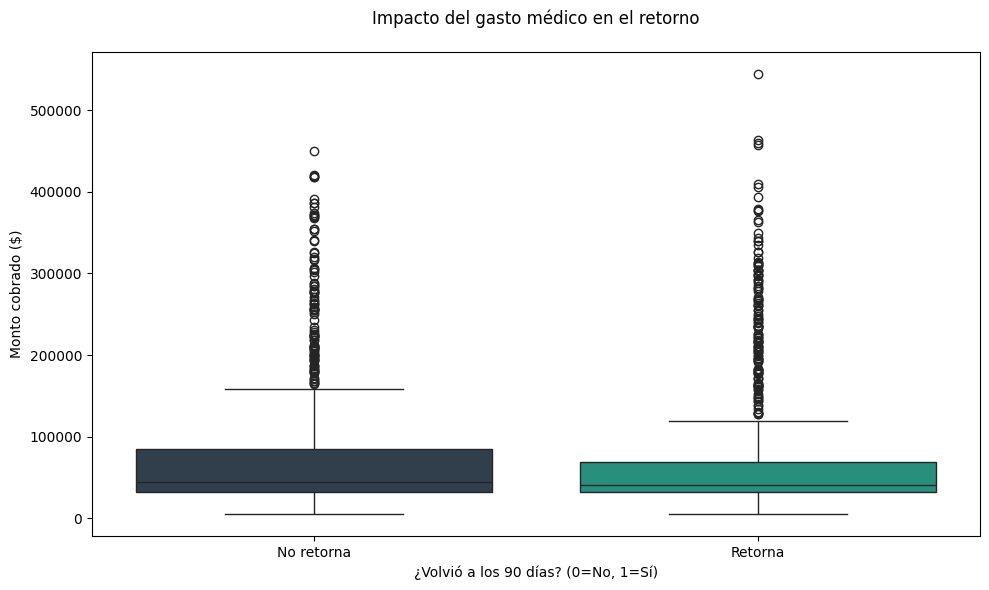

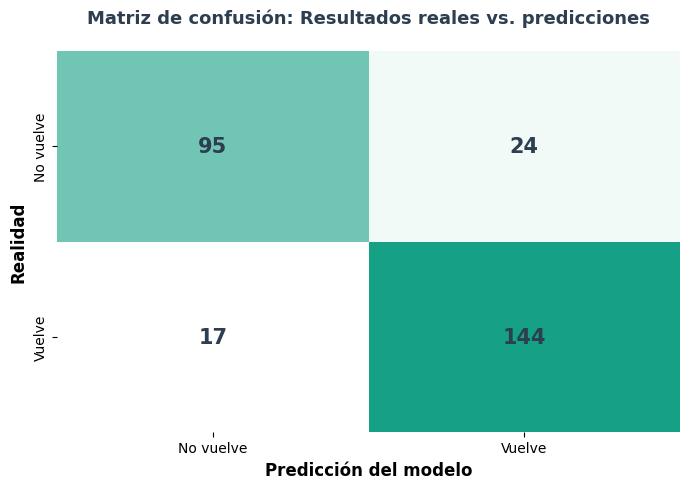

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


vetsur_palette = ["#2c3e50", "#16a085"]

def autolabel_vetsur(rects, ax):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 5),
                    textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold')

# 1. Gráfico de sucursal
plt.figure(figsize=(10, 6))
suc_data = df.groupby('sucursal')['retorno_90d'].mean().sort_values(ascending=False)
ax1 = plt.gca()
rects1 = ax1.bar(suc_data.index, suc_data.values,
                 color=[vetsur_palette[0], vetsur_palette[1]] * 4,
                 edgecolor='#34495e')

plt.title('Tasa de retorno por sucursal', fontsize=12, pad=20)
plt.ylabel('Probabilidad de retorno')
plt.xlabel('Sucursal')
plt.xticks(rotation=45)
plt.ylim(0, 1)
autolabel_vetsur(rects1, ax1)
plt.tight_layout()
plt.show()

# 2. Fidelidad según especie de mascota
plt.figure(figsize=(8, 6))
esp_data = df.groupby('especie')['retorno_90d'].mean().sort_values(ascending=False)
ax2 = plt.gca()
rects2 = ax2.bar(esp_data.index, esp_data.values,
                 color=[vetsur_palette[0], vetsur_palette[1]] * 2,
                 edgecolor='#34495e')

plt.title('Fidelidad según especie de mascota', fontsize=12, pad=20)
plt.ylabel('Probabilidad de retorno')
plt.xlabel('Especie')
plt.ylim(0, 1)
autolabel_vetsur(rects2, ax2)
plt.tight_layout()
plt.show()

# 3. Impacto del gasto médico en el retorno (BOXPLOT)
plt.figure(figsize=(10, 6))
sns.boxplot(x='retorno_90d', y='monto_cobrado', data=df,
            hue='retorno_90d', palette=vetsur_palette, legend=False)

plt.title('Impacto del gasto médico en el retorno', fontsize=12, pad=20)
plt.xlabel('¿Volvió a los 90 días? (0=No, 1=Sí)')
plt.ylabel('Monto cobrado ($)')
plt.xticks([0, 1], ['No retorna', 'Retorna'])
plt.tight_layout()
plt.show()

# 4. Matriz de confusión
from sklearn.metrics import confusion_matrix
from matplotlib.colors import LinearSegmentedColormap

cmap_vetsur_final = LinearSegmentedColormap.from_list("vetsur", ["#ffffff", "#16a085"])
cm = confusion_matrix(y_test, predicciones)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap=cmap_vetsur_final, cbar=False,
            xticklabels=['No vuelve', 'Vuelve'],
            yticklabels=['No vuelve', 'Vuelve'],
            annot_kws={"size": 15, "fontweight": "bold", "color": "#2c3e50"})

plt.title('Matriz de confusión: Resultados reales vs. predicciones',
          fontsize=13, fontweight='bold', pad=20, color="#2c3e50")
plt.ylabel('Realidad', fontsize=12, fontweight='bold')
plt.xlabel('Predicción del modelo', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()




# 4. Feature engineering

## Auditoría final de normalización

In [15]:
columnas_chequeo = ['sucursal', 'especie', 'tipo_atencion']

print("--- REVISIÓN DE CATEGORÍAS ---")
for col in columnas_chequeo:
    print(f"\nValores únicos en '{col}':")
    print(df[col].unique())

import re
def tiene_caracter_raro(texto):
    if pd.isna(texto): return False
    return bool(re.search(r'[^a-zA-Z0-9\s_]', str(texto)))

print("\n" + "="*30)
print("--- BUSCADOR DE CARÁCTERES BASURA---")
for col in columnas_chequeo:
    errores = df[df[col].apply(tiene_caracter_raro)][col].unique()
    if len(errores) > 0:
        print(f"Se encontró algo en '{col}': {errores}")
    else:
        print(f"'{col}' está 100% limpia.")

--- REVISIÓN DE CATEGORÍAS ---

Valores únicos en 'sucursal':
['providencia' 'ñuñoa' 'peñalolén' 'las_condes' 'san_miguel' 'la_florida'
 'pudahuel' 'maipú']

Valores únicos en 'especie':
['gato' 'perro' 'ave' 'exÃ³tico']

Valores únicos en 'tipo_atencion':
['consulta_general' 'hospitalización' 'consulta_especialidad' 'cirugía'
 'venta_producto']

--- BUSCADOR DE CARÁCTERES BASURA---
Se encontró algo en 'sucursal': ['ñuñoa' 'peñalolén' 'maipú']
Se encontró algo en 'especie': ['exÃ³tico']
Se encontró algo en 'tipo_atencion': ['hospitalización' 'cirugía']


In [16]:
df['especie'].value_counts()

,count
especie,
perro,802
gato,451
ave,90
exÃ³tico,57


## One-Hot Encoding

In [17]:
for col in df.columns:
    print(f"--- Columna: {col} ---")
    print(f"Tipo de dato: {df[col].dtype}")
    print(f"Nulos: {df[col].isnull().sum()}")

    if df[col].dtype == 'object':
        print(f"Valores únicos: {df[col].unique()}")
    else:
        print(f"Rango: min={df[col].min()} | max={df[col].max()}")
    print("\n")

--- Columna: paciente_id ---
Tipo de dato: object
Nulos: 0
Valores únicos: ['PAC_00419' 'PAC_00001' 'PAC_00002' ... 'PAC_01396' 'PAC_01398'
 'PAC_01399']


--- Columna: sucursal ---
Tipo de dato: object
Nulos: 0
Valores únicos: ['providencia' 'ñuñoa' 'peñalolén' 'las_condes' 'san_miguel' 'la_florida'
 'pudahuel' 'maipú']


--- Columna: especie ---
Tipo de dato: object
Nulos: 0
Valores únicos: ['gato' 'perro' 'ave' 'exÃ³tico']


--- Columna: raza_registrada ---
Tipo de dato: int64
Nulos: 0
Rango: min=0 | max=1


--- Columna: edad_mascota_anios ---
Tipo de dato: float64
Nulos: 0
Rango: min=0.1 | max=18.0


--- Columna: tipo_atencion ---
Tipo de dato: object
Nulos: 0
Valores únicos: ['consulta_general' 'hospitalización' 'consulta_especialidad' 'cirugía'
 'venta_producto']


--- Columna: diagnostico_texto ---
Tipo de dato: object
Nulos: 0
Valores únicos: ['control_rutina' 'tumor' 'dermatitis' 'fractura' 'artritis' 'artrítís'
 'esterilización' 'tumor_c' 'artritis_c' 'gastroenteritis' 'derma

In [18]:
import pandas as pd

df_limpio = df.drop(columns=['paciente_id', 'medico_id'])

df_final = pd.get_dummies(df_limpio, columns=['sucursal', 'especie', 'tipo_atencion', 'diagnostico_texto'], drop_first=False)

print("Columnas después del One-Hot Encoding:")
print(df_final.columns.tolist())
print(f"\nAhora tenemos {df_final.shape[1]} columnas listas para el modelo.")
df_final.head()

Columnas después del One-Hot Encoding:
['raza_registrada', 'edad_mascota_anios', 'monto_cobrado', 'costo_medicamento', 'dias_desde_ultima_visita', 'visitas_historicas', 'tiene_vacunas_al_dia', 'retorno_90d', 'sucursal_la_florida', 'sucursal_las_condes', 'sucursal_maipú', 'sucursal_peñalolén', 'sucursal_providencia', 'sucursal_pudahuel', 'sucursal_san_miguel', 'sucursal_ñuñoa', 'especie_ave', 'especie_exÃ³tico', 'especie_gato', 'especie_perro', 'tipo_atencion_cirugía', 'tipo_atencion_consulta_especialidad', 'tipo_atencion_consulta_general', 'tipo_atencion_hospitalización', 'tipo_atencion_venta_producto', 'diagnostico_texto_artritis', 'diagnostico_texto_artritis_c', 'diagnostico_texto_artrítís', 'diagnostico_texto_control_rutina', 'diagnostico_texto_control_rutina_c', 'diagnostico_texto_control_rutína', 'diagnostico_texto_dermatitis', 'diagnostico_texto_dermatitis_c', 'diagnostico_texto_dermatítís', 'diagnostico_texto_diabetes', 'diagnostico_texto_diabetes_c', 'diagnostico_texto_díabetes

,raza_registrada,edad_mascota_anios,monto_cobrado,costo_medicamento,dias_desde_ultima_visita,visitas_historicas,tiene_vacunas_al_dia,retorno_90d,sucursal_la_florida,sucursal_las_condes,...,diagnostico_texto_gastroenteritis_c,diagnostico_texto_gastroenterítís,diagnostico_texto_otitis,diagnostico_texto_otitis_c,diagnostico_texto_otítís,diagnostico_texto_parvovirus,diagnostico_texto_parvovirus_c,diagnostico_texto_parvovírus,diagnostico_texto_tumor,diagnostico_texto_tumor_c
0,0,4.7,38900,3500.0,462,3,0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
1,0,0.6,234200,34600.0,112,2,0,0,False,False,...,False,False,False,False,False,False,False,False,True,False
2,0,1.1,147800,31100.0,42,4,0,1,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1,5.9,82600,24700.0,187,5,1,0,False,True,...,False,False,False,False,False,False,False,False,False,False
4,1,0.9,36300,5800.0,111,7,1,1,False,False,...,False,False,False,False,False,False,False,False,False,False


In [19]:
print("--- INFO DEL DATASET FINAL ---")
print(df_final.info())

print("\n--- PRIMERAS 5 FILAS ---")
print(df_final.head())

--- INFO DEL DATASET FINAL ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1400 entries, 0 to 1399
Data columns (total 53 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   raza_registrada                      1400 non-null   int64  
 1   edad_mascota_anios                   1400 non-null   float64
 2   monto_cobrado                        1400 non-null   int64  
 3   costo_medicamento                    1400 non-null   float64
 4   dias_desde_ultima_visita             1400 non-null   int64  
 5   visitas_historicas                   1400 non-null   int64  
 6   tiene_vacunas_al_dia                 1400 non-null   int64  
 7   retorno_90d                          1400 non-null   int64  
 8   sucursal_la_florida                  1400 non-null   bool   
 9   sucursal_las_condes                  1400 non-null   bool   
 10  sucursal_maipú                       1400 non-null   bool   
 11 

# Modelo predictivo y evaluación

## Identificación de variables clave (análisis de importancia)
En esta etapa entrenamos un modelo preliminar con la totalidad de las variables procesadas (41 características) para identificar cuáles tienen un impacto real en el retorno del cliente.

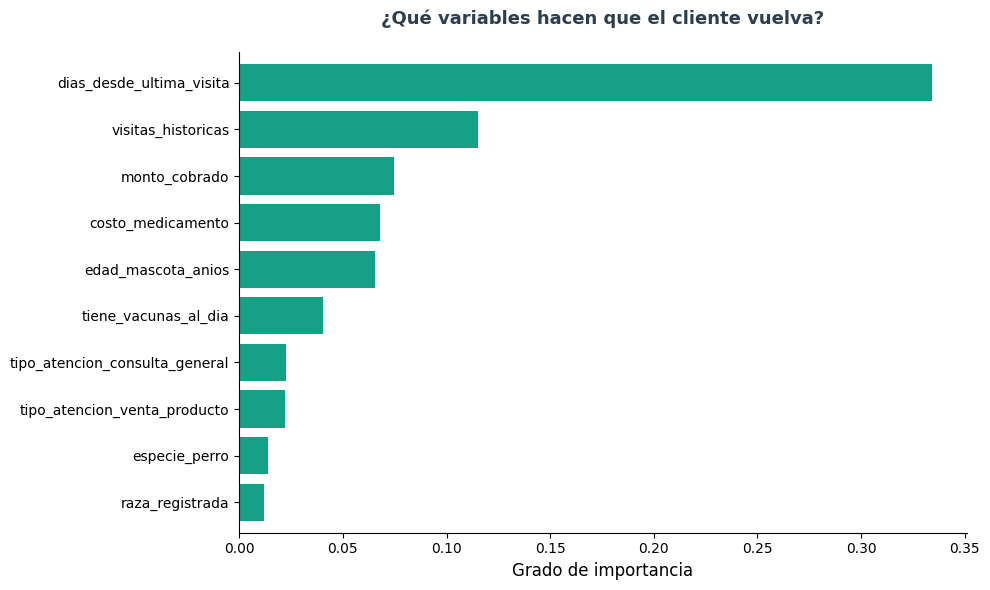

Precisión del modelo: 0.84


In [20]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X = df_final.drop(columns=['retorno_90d'])
y = df_final['retorno_90d']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


modelo = RandomForestClassifier(n_estimators=100, random_state=42)
modelo.fit(X_train, y_train)


importancias = pd.Series(modelo.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
importancias.head(10).plot(kind='barh', color=vetsur_palette[1], width=0.8)

plt.title('¿Qué variables hacen que el cliente vuelva?', fontsize=13, pad=20, fontweight='bold', color=vetsur_palette[0])
plt.xlabel('Grado de importancia', fontsize=12)
plt.gca().invert_yaxis()

plt.grid(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print(f"Precisión del modelo: {modelo.score(X_test, y_test):.2f}")


## Entrenamiento del modelo final optimizado (7 variables)

--- Métricas del modelo optimizado (7 variables) ---
Precisión (Accuracy): 0.85
Recall: 0.89


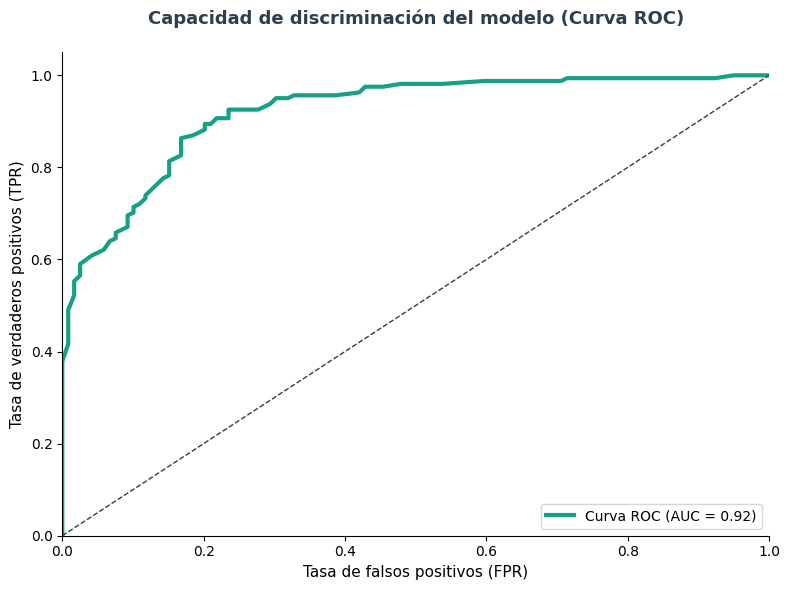

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, roc_curve, roc_auc_score
import matplotlib.pyplot as plt

columnas_top_7 = [
    'dias_desde_ultima_visita',
    'visitas_historicas',
    'monto_cobrado',
    'costo_medicamento',
    'edad_mascota_anios',
    'tiene_vacunas_al_dia',
    'tipo_atencion_venta_producto'
]

X = df_final[columnas_top_7]
y = df_final['retorno_90d']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


modelo_optimizado = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_optimizado.fit(X_train, y_train)

predicciones = modelo_optimizado.predict(X_test)
print("--- Métricas del modelo optimizado (7 variables) ---")
print(f"Precisión (Accuracy): {accuracy_score(y_test, predicciones):.2f}")
print(f"Recall: {recall_score(y_test, predicciones):.2f}")

probs = modelo_optimizado.predict_proba(X_test)[:, 1]
fpr, tpr, umbrales = roc_curve(y_test, probs)
auc_score = roc_auc_score(y_test, probs)

plt.figure(figsize=(8, 6))

plt.plot(fpr, tpr, color=vetsur_palette[1], lw=3, label=f'Curva ROC (AUC = {auc_score:.2f})')

plt.plot([0, 1], [0, 1], color=vetsur_palette[0], lw=1, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

plt.xlabel('Tasa de falsos positivos (FPR)', fontsize=11)
plt.ylabel('Tasa de verdaderos positivos (TPR)', fontsize=11)
plt.title('Capacidad de discriminación del modelo (Curva ROC)', fontsize=13, pad=20, color=vetsur_palette[0], fontweight='bold')
plt.legend(loc="lower right", frameon=True)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


**Conclusión del análisis:** Tras observar los resultados, se determinó que el "ruido" de las variables menos importantes podía afectar la generalización del modelo. Por lo tanto, se seleccionaron las **7 variables principales** para construir el modelo final optimizado.

## Comparativa de rendimiento: modelo original vs. modelo optimizado
Para validar la optimización del nuevo modelo de Random Forest, se comparó el desempeño del modelo inicial (44 columnas) contra el modelo optimizado (7 columnas). El objetivo es demostrar que la simplificación del modelo no compromete la capacidad predictiva necesaria para la toma de decisiones en VetSur.

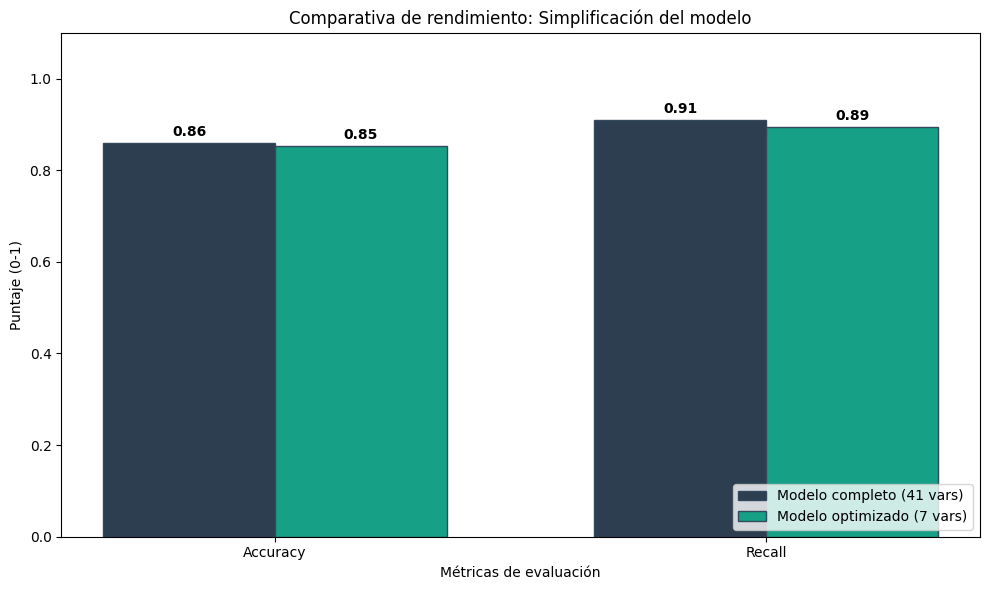

In [22]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, recall_score

labels = ['Accuracy', 'Recall']
modelo_completo = [0.86, 0.91]
modelo_optimizado_vals = [
    accuracy_score(y_test, predicciones),
    recall_score(y_test, predicciones)
]

x = np.arange(len(labels))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 6))

rects1 = ax.bar(x - width/2, modelo_completo, width, label='Modelo completo (41 vars)',
                color=vetsur_palette[0], edgecolor='#34495e')
rects2 = ax.bar(x + width/2, modelo_optimizado_vals, width, label='Modelo optimizado (7 vars)',
                color=vetsur_palette[1], edgecolor='#34495e')

ax.set_ylabel('Puntaje (0-1)')
ax.set_title('Comparativa de rendimiento: Simplificación del modelo', fontsize=12)
ax.set_xlabel('Métricas de evaluación')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1.1)
ax.legend(loc='lower right')

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()


## Comparativa con alternativas

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, f1_score, roc_auc_score

modelos = {
    "Random Forest (Elegido)": RandomForestClassifier(n_estimators=100, random_state=42),
    "Regresión Logística": LogisticRegression(max_iter=5000),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

print("--- REPORTE COMPARATIVO VETSUR ---")
print(f"{'Modelo':<25} | {'Acc':<6} | {'Recall':<6} | {'F1':<6} | {'AUC':<6}")
print("-" * 60)

for nombre, mod in modelos.items():
    mod.fit(X_train, y_train)
    preds = mod.predict(X_test)
    probs = mod.predict_proba(X_test)[:, 1]

    print(f"{nombre:<25} | "
          f"{accuracy_score(y_test, preds):.2f}   | "
          f"{recall_score(y_test, preds):.2f}    | "
          f"{f1_score(y_test, preds):.2f}   | "
          f"{roc_auc_score(y_test, probs):.2f}")


--- REPORTE COMPARATIVO VETSUR ---
Modelo                    | Acc    | Recall | F1     | AUC   
------------------------------------------------------------
Random Forest (Elegido)   | 0.85   | 0.89    | 0.88   | 0.92
Regresión Logística       | 0.85   | 0.87    | 0.87   | 0.94
Gradient Boosting         | 0.84   | 0.88    | 0.86   | 0.92


## Validación cruzada

In [47]:
from sklearn.model_selection import cross_val_score
import pandas as pd

metrics_map = {
    'accuracy': 'Accuracy',
    'recall': 'Recall',
    'f1': 'F1',
    'roc_auc': 'AUC'
}

cv_results = {}
for internal_name, pretty_name in metrics_map.items():
    scores = cross_val_score(modelo_optimizado, X, y, cv=5, scoring=internal_name)
    cv_results[pretty_name] = scores

df_total_cv = pd.DataFrame(cv_results)
df_plot = df_total_cv.melt(var_name='Métrica', value_name='Puntaje')

Datos creados con nombres personalizados.


/tmp/ipykernel_5550/4251047355.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x='Métrica', y='Puntaje', data=df_plot,


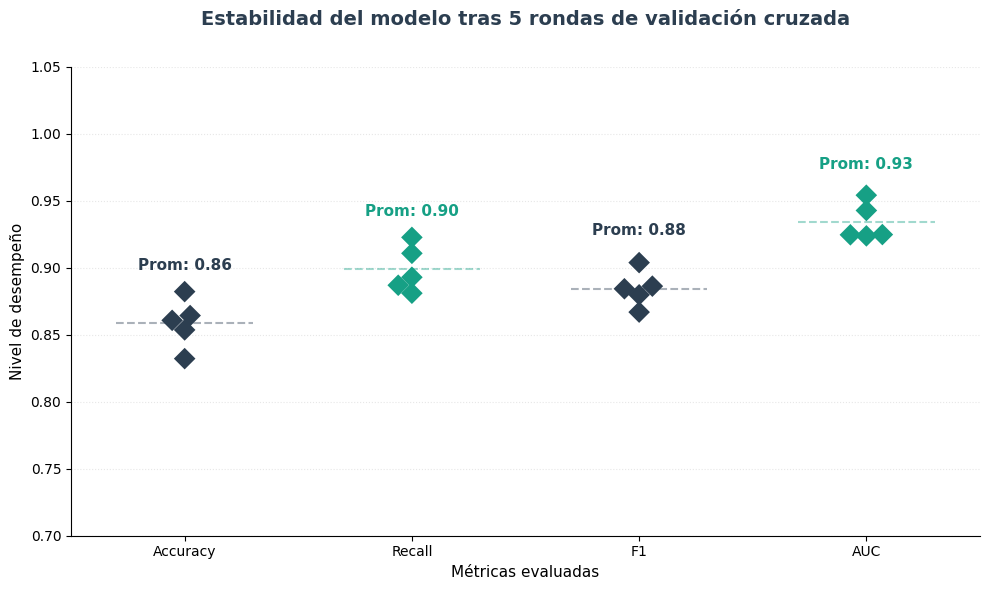

In [48]:
plt.figure(figsize=(10, 6))

colores_vetsur = [vetsur_palette[0], vetsur_palette[1], vetsur_palette[0], vetsur_palette[1]]

sns.swarmplot(x='Métrica', y='Puntaje', data=df_plot,
              palette=colores_vetsur, size=11, marker='D')

for i, col in enumerate(df_total_cv.columns):
    promedio = df_total_cv[col].mean()
    color_actual = colores_vetsur[i]

    plt.axhline(y=promedio, xmin=(i*0.25)+0.05, xmax=((i+1)*0.25)-0.05,
                color=color_actual, linestyle='--', alpha=0.4)

    plt.text(i, promedio + 0.04, f"Prom: {promedio:.2f}",
             ha='center', fontsize=11, fontweight='bold', color=color_actual)

plt.title('Estabilidad del modelo tras 5 rondas de validación cruzada',
          fontsize=14, pad=30, fontweight='bold', color=vetsur_palette[0])

plt.ylabel('Nivel de desempeño', fontsize=11)
plt.xlabel('Métricas evaluadas', fontsize=11)
plt.ylim(0.70, 1.05)
plt.grid(axis='y', linestyle=':', alpha=0.3)
sns.despine()

plt.tight_layout()
plt.show()


# Exportación de los archivos para deploy

In [26]:
import joblib
import json


joblib.dump(modelo_optimizado, 'modelo_vetsur.pkl')
columnas = X.columns.tolist()

with open('columnas_vetsur.json', 'w') as f:
    json.dump(columnas, f)

print(f"Archivos generados: modelo_vetsur.pkl y columnas_vetsur.json")
print(f"Variables exportadas: {columnas}")

Archivos generados: modelo_vetsur.pkl y columnas_vetsur.json
Variables exportadas: ['dias_desde_ultima_visita', 'visitas_historicas', 'monto_cobrado', 'costo_medicamento', 'edad_mascota_anios', 'tiene_vacunas_al_dia', 'tipo_atencion_venta_producto']


# Cálculos justificativos para el informe

# Gráficos extras para el informe

In [27]:
# 1. BRECHA DE VACUNAS
# Comparamos grupos: Vemos que de 100 vacunados vuelven 67, y de 100 NO vacunados vuelven 49.
# La "Brecha" es ese 18% de diferencia que nos dice que la vacuna amarra al cliente.
tasa_retorno_vacuna = df.groupby('tiene_vacunas_al_dia')['retorno_90d'].mean()
diff_puntos = (tasa_retorno_vacuna[1] - tasa_retorno_vacuna[0]) * 100
print(f"1. Diferencia de retorno por vacunas: {diff_puntos:.1f}%")

# INGRESO EXTRA (SIMULACIÓN DE ESCENARIO):
# 1. Miramos a los que NO vacunan y vemos que vuelven poco.
# 2. Calculamos cuánta gente extra vendría si lográramos que vacunen
#    y se porten como los clientes leales (los que sí vacunan).
# 3. Esa "gente extra" la multiplicamos por lo que gasta un cliente promedio.
# Son 8 millones que hoy se nos escapan por no tener un sistema de recordatorios de vacunación.
clientes_sin_vacuna = df[df['tiene_vacunas_al_dia'] == 0]
retornos_actuales = clientes_sin_vacuna['retorno_90d'].sum()
retornos_potenciales = len(clientes_sin_vacuna) * tasa_retorno_vacuna[1]
nuevos_retornos = retornos_potenciales - retornos_actuales
ingreso_extra_estimado = nuevos_retornos * df['monto_cobrado'].mean()
print(f"2. Plata extra si todos se vacunan: ${ingreso_extra_estimado:,.0f}")

# 3. GANANCIA LIMPIA (MARGEN REAL)
# No todo lo que entra a la caja es utilidad. Restamos: [Cobro total] - [Costo del remedio].
# Así vemos que las cirugías son las que más pagan, no la venta de productos.
df['margen_bruto'] = df['monto_cobrado'] - df['costo_medicamento']
margen_por_tipo = df.groupby('tipo_atencion')['margen_bruto'].mean().sort_values(ascending=False)
print("\n3. Margen real por servicio (lo que nos queda en el bolsillo):")
print(margen_por_tipo)

# 4. CLIENTES QUE SE OLVIDARON
# Buscamos a los 133 que no vienen hace más de 6 meses y que el modelo dice que no volverán.
# Sumamos lo que ellos solían gastar: Perderlos significa dejar de percibir casi 10 millones.
fuga_riesgo = df[(df['dias_desde_ultima_visita'] > 180) & (df['retorno_90d'] == 0)]
valor_fuga = len(fuga_riesgo) * fuga_riesgo['monto_cobrado'].mean()
print(f"\n4. Pacientes perdidos (> 6 meses): {len(fuga_riesgo)}")
print(f"   Dinero en riesgo de perderse: ${valor_fuga:,.0f}")

# 5. LOS CLIENTES VIP
# Miramos a los que han venido más de 5 veces. Casi todos (82%) vuelven siempre.
# Conclusión: Es más barato cuidar a estos 307 fieles que salir a buscar clientes nuevos.
leales = df[df['visitas_historicas'] > 5]
print(f"\n5. Clientes fieles (> 5 visitas): {len(leales)}")
print(f"   Tasa de retorno de estos clientes: {leales['retorno_90d'].mean()*100:.1f}%")

1. Diferencia de retorno por vacunas: 18.0%
2. Plata extra si todos se vacunan: $8,051,006

3. Margen real por servicio (lo que nos queda en el bolsillo):
tipo_atencion
cirugía                  210572.560976
hospitalización          150064.754098
consulta_especialidad     48897.419355
consulta_general          27629.951691
venta_producto            22720.765027
Name: margen_bruto, dtype: float64

4. Pacientes perdidos (> 6 meses): 133
   Dinero en riesgo de perderse: $9,903,100

5. Clientes fieles (> 5 visitas): 307
   Tasa de retorno de estos clientes: 82.7%
